<a href="https://colab.research.google.com/github/afllaabdi/tugas_NLP/blob/main/Salinan_dari_NLP(definitive_edition)ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **DATA CLEANING**

In [ ]:
# =========================
# INSTALL LIBRARY (JALANKAN SEKALI)
# =========================
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.2 MB/s eta 0:00:00


Pada tahap ini, kami menggunakan library Sastrawi untuk melakukan proses stemming pada teks bahasa Indonesia. Library ini dipilih karena mampu mengubah kata berimbuhan menjadi kata dasar secara akurat.

In [ ]:
# ========================
# IMPORT
# ========================
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# =========================
# MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Pada tahap ini, kami menggunakan beberapa library utama, yaitu:

- pandas untuk mengelola dan memproses dataset
- re untuk melakukan pembersihan teks menggunakan regular expression
- Sastrawi untuk proses stemming

Selain itu, kami menghubungkan Google Colab dengan Google Drive agar dataset dapat diakses secara langsung.

In [ ]:
# =========================
# LOAD DATA
# =========================
file_path = '/content/drive/MyDrive/dataset/news_title_filter.csv'

df = pd.read_csv(file_path)

print("Jumlah data:", df.shape)
df.head(5)

Jumlah data: (4444, 4)


,date,url,title,category
0,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,"Terbitkan Resi Pertama, SRG Konawe Bantu Ketah...",finance
1,02/26/2020,https://finance.detik.com/properti/d-4915865/j...,Jokowi Janji Buka 3 Juta Lapangan Kerja di Ibu...,finance
2,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,"Banyak Slot Penerbangan Internasional Kosong, ...",finance
3,02/26/2020,https://finance.detik.com/energi/d-4915883/atu...,Aturan Wajib Penggunaan Kapal RI Bisa Ganggu E...,finance
4,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,"Izin Impor Lelet, Waspada Ekspor RI Makin Loyo",finance


Pada tahap ini, kami memuat dataset dari Google Drive menggunakan library pandas. Dataset yang digunakan berisi judul berita yang akan diproses lebih lanjut. Kami juga menampilkan sebagian data untuk memahami struktur awal dataset.

In [ ]:
# =========================
# COPY DATA
# =========================
df['clean_text'] = df['title']

df[['title', 'clean_text']].head()

,title,clean_text
0,"Terbitkan Resi Pertama, SRG Konawe Bantu Ketah...","Terbitkan Resi Pertama, SRG Konawe Bantu Ketah..."
1,Jokowi Janji Buka 3 Juta Lapangan Kerja di Ibu...,Jokowi Janji Buka 3 Juta Lapangan Kerja di Ibu...
2,"Banyak Slot Penerbangan Internasional Kosong, ...","Banyak Slot Penerbangan Internasional Kosong, ..."
3,Aturan Wajib Penggunaan Kapal RI Bisa Ganggu E...,Aturan Wajib Penggunaan Kapal RI Bisa Ganggu E...
4,"Izin Impor Lelet, Waspada Ekspor RI Makin Loyo","Izin Impor Lelet, Waspada Ekspor RI Makin Loyo"


Pada tahap ini, kami membuat salinan dari kolom title ke kolom baru clean_text. Hal ini dilakukan agar data asli tetap terjaga dan proses cleaning hanya dilakukan pada kolom hasil salinan.

In [ ]:
# =========================
# LOWERCASE
# =========================
df['clean_text'] = df['clean_text'].str.lower()

df[['title', 'clean_text']].head(100)

,title,clean_text
0,"Terbitkan Resi Pertama, SRG Konawe Bantu Ketah...","terbitkan resi pertama, srg konawe bantu ketah..."
1,Jokowi Janji Buka 3 Juta Lapangan Kerja di Ibu...,jokowi janji buka 3 juta lapangan kerja di ibu...
2,"Banyak Slot Penerbangan Internasional Kosong, ...","banyak slot penerbangan internasional kosong, ..."
3,Aturan Wajib Penggunaan Kapal RI Bisa Ganggu E...,aturan wajib penggunaan kapal ri bisa ganggu e...
4,"Izin Impor Lelet, Waspada Ekspor RI Makin Loyo","izin impor lelet, waspada ekspor ri makin loyo"
...,...,...
95,"Harga Pangan Melonjak di Tengah Corona, Ini Bi...","harga pangan melonjak di tengah corona, ini bi..."
96,"Siasati Dampak Corona, Peternak Jual Ayam Door...","siasati dampak corona, peternak jual ayam door..."
97,"Surplus Sekitar 128.000 Ton, Persediaan Beras ...","surplus sekitar 128.000 ton, persediaan beras ..."
98,"Tak Perlu Keluar Rumah, Urus Izin Impor Pakan ...","tak perlu keluar rumah, urus izin impor pakan ..."


Kami menggunakan lowercase untuk menyamakan format teks agar konsisten.

In [ ]:
# =========================
# HITUNG JUMLAH NOISE SEBELUM DIHAPUS
# =========================
jumlah_video = df['clean_text'].str.count('video:').sum()
jumlah_foto = df['clean_text'].str.count('foto:').sum()

print(f"Jumlah 'video:' sebelum dihapus: {jumlah_video}")
print(f"Jumlah 'foto:' sebelum dihapus: {jumlah_foto}")
print(f"Total noise: {jumlah_video + jumlah_foto}")

Jumlah 'video:' sebelum dihapus: 3
Jumlah 'foto:' sebelum dihapus: 8
Total noise: 11


In [ ]:
# =========================
# HAPUS NOISE
# =========================
df['clean_text'] = df['clean_text'].str.replace('video:', '', regex=False)
df['clean_text'] = df['clean_text'].str.replace('foto:', '', regex=False)

df[['title', 'clean_text']].head(5)

,title,clean_text
0,"Terbitkan Resi Pertama, SRG Konawe Bantu Ketah...","terbitkan resi pertama, srg konawe bantu ketah..."
1,Jokowi Janji Buka 3 Juta Lapangan Kerja di Ibu...,jokowi janji buka 3 juta lapangan kerja di ibu...
2,"Banyak Slot Penerbangan Internasional Kosong, ...","banyak slot penerbangan internasional kosong, ..."
3,Aturan Wajib Penggunaan Kapal RI Bisa Ganggu E...,aturan wajib penggunaan kapal ri bisa ganggu e...
4,"Izin Impor Lelet, Waspada Ekspor RI Makin Loyo","izin impor lelet, waspada ekspor ri makin loyo"


Pada tahap ini, kami menghapus kata-kata yang dianggap sebagai noise. Kata-kata tersebut tidak memiliki makna penting dalam analisis sehingga perlu dihilangkan.

In [ ]:
# =========================
# HITUNG JUMLAH NOISE SETELAH DIHAPUS
# =========================
jumlah_video_after = df['clean_text'].str.count('video:').sum()
jumlah_foto_after = df['clean_text'].str.count('foto:').sum()

print(f"Jumlah 'video:' setelah dihapus: {jumlah_video_after}")
print(f"Jumlah 'foto:' setelah dihapus: {jumlah_foto_after}")
print(f"Total noise setelah dihapus: {jumlah_video_after + jumlah_foto_after}")

Jumlah 'video:' setelah dihapus: 0
Jumlah 'foto:' setelah dihapus: 0
Total noise setelah dihapus: 0


In [ ]:
# =========================
# HAPUS ANGKA
# =========================
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'\d+', '', str(x)))

df[['title', 'clean_text']].head()

,title,clean_text
0,"Terbitkan Resi Pertama, SRG Konawe Bantu Ketah...","terbitkan resi pertama, srg konawe bantu ketah..."
1,Jokowi Janji Buka 3 Juta Lapangan Kerja di Ibu...,jokowi janji buka juta lapangan kerja di ibu ...
2,"Banyak Slot Penerbangan Internasional Kosong, ...","banyak slot penerbangan internasional kosong, ..."
3,Aturan Wajib Penggunaan Kapal RI Bisa Ganggu E...,aturan wajib penggunaan kapal ri bisa ganggu e...
4,"Izin Impor Lelet, Waspada Ekspor RI Makin Loyo","izin impor lelet, waspada ekspor ri makin loyo"


Pada tahap ini, kami menghapus seluruh angka dari teks karena angka tidak memberikan kontribusi signifikan dalam analisis berbasis teks.

In [ ]:
# =========================
# HAPUS SIMBOL
# =========================
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))

df[['title', 'clean_text']].head()

,title,clean_text
0,"Terbitkan Resi Pertama, SRG Konawe Bantu Ketah...",terbitkan resi pertama srg konawe bantu ketaha...
1,Jokowi Janji Buka 3 Juta Lapangan Kerja di Ibu...,jokowi janji buka juta lapangan kerja di ibu ...
2,"Banyak Slot Penerbangan Internasional Kosong, ...",banyak slot penerbangan internasional kosong i...
3,Aturan Wajib Penggunaan Kapal RI Bisa Ganggu E...,aturan wajib penggunaan kapal ri bisa ganggu e...
4,"Izin Impor Lelet, Waspada Ekspor RI Makin Loyo",izin impor lelet waspada ekspor ri makin loyo


Pada tahap ini, kami menghapus karakter selain huruf dan spasi, seperti tanda baca dan simbol. Hal ini dilakukan untuk memastikan bahwa teks hanya berisi kata-kata yang relevan.

In [ ]:
# =========================
# HAPUS SPASI BERLEBIH
# =========================
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

df[['title', 'clean_text']].head()

,title,clean_text
0,"Terbitkan Resi Pertama, SRG Konawe Bantu Ketah...",terbitkan resi pertama srg konawe bantu ketaha...
1,Jokowi Janji Buka 3 Juta Lapangan Kerja di Ibu...,jokowi janji buka juta lapangan kerja di ibu k...
2,"Banyak Slot Penerbangan Internasional Kosong, ...",banyak slot penerbangan internasional kosong i...
3,Aturan Wajib Penggunaan Kapal RI Bisa Ganggu E...,aturan wajib penggunaan kapal ri bisa ganggu e...
4,"Izin Impor Lelet, Waspada Ekspor RI Makin Loyo",izin impor lelet waspada ekspor ri makin loyo


Pada tahap ini, kami melakukan normalisasi spasi dengan menghapus spasi berlebih agar teks menjadi lebih rapi dan konsisten.

In [ ]:
# =========================
# STEMMING
# =========================
factory = StemmerFactory()
stemmer = factory.create_stemmer()

df['clean_text'] = df['clean_text'].apply(lambda x: stemmer.stem(x))

df[['title', 'clean_text']].head(5)

,title,clean_text
0,"Terbitkan Resi Pertama, SRG Konawe Bantu Ketah...",terbit resi pertama srg konawe bantu tahan pan...
1,Jokowi Janji Buka 3 Juta Lapangan Kerja di Ibu...,jokowi janji buka juta lapang kerja di ibu kot...
2,"Banyak Slot Penerbangan Internasional Kosong, ...",banyak slot terbang internasional kosong ini l...
3,Aturan Wajib Penggunaan Kapal RI Bisa Ganggu E...,atur wajib guna kapal ri bisa ganggu ekspor ba...
4,"Izin Impor Lelet, Waspada Ekspor RI Makin Loyo",izin impor lelet waspada ekspor ri makin loyo


Pada tahap ini, kami menggunakan algoritma stemming dengan library Sastrawi untuk mengubah kata menjadi bentuk dasar. Proses ini bertujuan untuk menyederhanakan variasi kata sehingga memiliki representasi yang sama.

In [ ]:
#StopWord
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()

noise_pangan = [
    'corona','masker','rp','ri','antam','emas','as','india',
    'new','york','juta','ribu','miliar','detik','video','foto',
    'china','covid','hingga','jokowi'
]
stopwords.extend(noise_pangan)

def clean_noise(text):
    return " ".join([w for w in str(text).split() if w not in stopwords])

df['clean_text'] = df['clean_text'].apply(clean_noise)

In [ ]:
# =========================
# HASIL CLEANING
# =========================
df[['title', 'clean_text']].head(10)

,title,clean_text
0,"Terbitkan Resi Pertama, SRG Konawe Bantu Ketah...",terbit resi pertama srg konawe bantu tahan pan...
1,Jokowi Janji Buka 3 Juta Lapangan Kerja di Ibu...,janji buka lapang kerja ibu kota negara baru
2,"Banyak Slot Penerbangan Internasional Kosong, ...",banyak slot terbang internasional kosong langk...
3,Aturan Wajib Penggunaan Kapal RI Bisa Ganggu E...,atur wajib kapal ganggu ekspor batu bara
4,"Izin Impor Lelet, Waspada Ekspor RI Makin Loyo",izin impor lelet waspada ekspor makin loyo
5,Inflasi Rendah Karena Daya Beli Turun? Ini Kat...,inflasi rendah daya beli turun kata bi
6,CT Bicara Inflasi Rendah: Ekonomi Membaik atau...,ct bicara inflasi rendah ekonomi baik daya bel...
7,"Usai Cetak Rekor, Harga Emas Antam Hari Ini Tu...",usai cetak rekor harga hari turun ceceng
8,Ekspor Impor Bisa Mandek Gara-gara Banjir,ekspor impor mandek garagara banjir
9,Diskon Liburan hingga Tambahan Rp 50.000 Kartu...,diskon libur tambah kartu sembako tepis


Pada tahap ini, kami menampilkan hasil akhir dari proses data cleaning untuk memastikan bahwa semua tahapan telah berjalan dengan baik.

In [ ]:
# =========================
# SAVE DATA
# =========================
save_path = '/content/drive/MyDrive/dataset/dataset_clean_final.csv'

df.to_csv(save_path, index=False)

print("Dataset berhasil disimpan!")

Dataset berhasil disimpan!


Pada tahap ini, kami menyimpan hasil data cleaning ke dalam file CSV agar dapat digunakan pada tahap berikutnya, seperti transformasi atau pemodelan.

## **DATA TRANSFORM**

In [ ]:
# =========================
# LOAD DATA
# =========================
import pandas as pd

file_path = '/content/drive/MyDrive/dataset/dataset_clean_final.csv'
df = pd.read_csv(file_path)

print("Jumlah data (baris, kolom):", df.shape)
df.head(4)

Jumlah data (baris, kolom): (4444, 5)


,date,url,title,category,clean_text
0,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,"Terbitkan Resi Pertama, SRG Konawe Bantu Ketah...",finance,terbit resi pertama srg konawe bantu tahan pan...
1,02/26/2020,https://finance.detik.com/properti/d-4915865/j...,Jokowi Janji Buka 3 Juta Lapangan Kerja di Ibu...,finance,janji buka lapang kerja ibu kota negara baru
2,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,"Banyak Slot Penerbangan Internasional Kosong, ...",finance,banyak slot terbang internasional kosong langk...
3,02/26/2020,https://finance.detik.com/energi/d-4915883/atu...,Aturan Wajib Penggunaan Kapal RI Bisa Ganggu E...,finance,atur wajib kapal ganggu ekspor batu bara


Pada tahap ini, kami memuat dataset hasil cleaning dan menampilkan 4 data pertama untuk melihat struktur awal data.

In [ ]:
# =========================
# INFO DATASET
# =========================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4444 entries, 0 to 4443
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        4444 non-null   object
 1   url         4444 non-null   object
 2   title       4444 non-null   object
 3   category    4444 non-null   object
 4   clean_text  4444 non-null   object
dtypes: object(5)
memory usage: 173.7+ KB


In [ ]:
def label_sentiment(text):
    positive = ['turun','murah','stabil','bantuan','subsidi','membaik','lancar','normal','sejahtera']
    negative = ['naik','mahal','langka','krisis','melonjak','ganggu','lelet','loyo','rugi','impor']

    pos = sum(word in text for word in positive)
    neg = sum(word in text for word in negative)

    if pos > neg:
        return "positif"
    elif neg > pos:
        return "negatif"
    else:
        return "netral"

df['label'] = df['clean_text'].apply(label_sentiment)

In [ ]:
# =========================
# IMPORT
# =========================
import pandas as pd
import numpy as np
import re

# =========================
# FILTERING (SESUAI LAPORAN)
# =========================

keywords = [
    # inti topik
    'pangan','ketahanan','sembako','beras','bahan pokok',

    # harga & ekonomi
    'harga','inflasi','mahal','murah','naik','turun',

    # distribusi & akses
    'distribusi','akses','pasokan','ketersediaan','stok','langka',

    # kebijakan pemerintah
    'impor','ekspor','kebijakan','subsidi','bantuan','pemerintah',

    # ekonomi & kondisi
    'ekonomi','krisis','global','domestik',

    # dampak sosial
    'masyarakat','kesejahteraan','petani'
]

# 🔥 penting: escape keyword biar aman regex
pattern = '|'.join([re.escape(k) for k in keywords])

df_filtered = df[
    df['clean_text'].str.contains(pattern, case=False, na=False)
].copy()

print("Jumlah data sebelum:", len(df))
print("Jumlah data setelah filtering:", len(df_filtered))


# =========================
# LABELING (PASTIKAN ADA)
# =========================
if 'label' not in df_filtered.columns:
    df_filtered['label'] = df_filtered['clean_text'].apply(label_sentiment)


# =========================
# FEATURE EXTRACTION
# =========================

# panjang teks
df_filtered['text_length'] = df_filtered['clean_text'].str.len()

# jumlah kata
df_filtered['word_count'] = df_filtered['clean_text'].apply(lambda x: len(str(x).split()))

# rata-rata panjang kata
df_filtered['avg_word_length'] = df_filtered['clean_text'].apply(
    lambda x: round(
        np.mean([len(word) for word in str(x).split()]), 2
    ) if len(str(x).split()) > 0 else 0
)


# =========================
# TABEL HASIL
# =========================
feature_table = df_filtered[[
    'clean_text',
    'label',
    'text_length',
    'word_count',
    'avg_word_length'
]]

print("\n=== HASIL FEATURE EXTRACTION ===")
display(feature_table.head(50))

Jumlah data sebelum: 4444
Jumlah data setelah filtering: 3114

=== HASIL FEATURE EXTRACTION ===


,clean_text,label,text_length,word_count,avg_word_length
0,terbit resi pertama srg konawe bantu tahan pan...,netral,58,9,5.56
2,banyak slot terbang internasional kosong langk...,negatif,55,7,7.00
3,atur wajib kapal ganggu ekspor batu bara,negatif,40,7,4.86
4,izin impor lelet waspada ekspor makin loyo,negatif,42,7,5.14
5,inflasi rendah daya beli turun kata bi,positif,38,7,4.57
6,ct bicara inflasi rendah ekonomi baik daya bel...,positif,53,9,5.00
7,usai cetak rekor harga hari turun ceceng,positif,40,7,4.86
8,ekspor impor mandek garagara banjir,negatif,35,5,6.20
9,diskon libur tambah kartu sembako tepis,netral,39,6,5.67
11,harga ayam potong bandung capai,netral,31,5,5.40


Pada tahap ini, kami melakukan ekstraksi fitur dasar dari teks, yaitu:

- panjang teks
- jumlah kata
- rata-rata panjang kata

Fitur ini digunakan untuk merepresentasikan karakteristik teks dalam bentuk numerik.

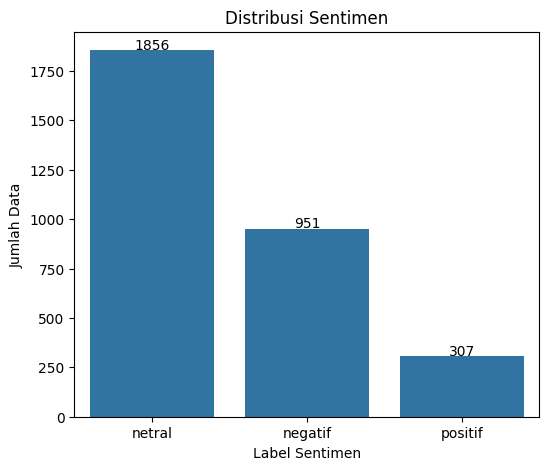

In [ ]:
# =========================================================
# VISUALISASI DISTRIBUSI SENTIMEN
# =========================================================

sentimen_count = df_filtered['label'].value_counts()

plt.figure(figsize=(6,5))

sns.barplot(
    x=sentimen_count.index,
    y=sentimen_count.values
)

plt.title('Distribusi Sentimen')
plt.xlabel('Label Sentimen')
plt.ylabel('Jumlah Data')

for i, v in enumerate(sentimen_count.values):
    plt.text(i, v+5, str(v), ha='center')

plt.show()

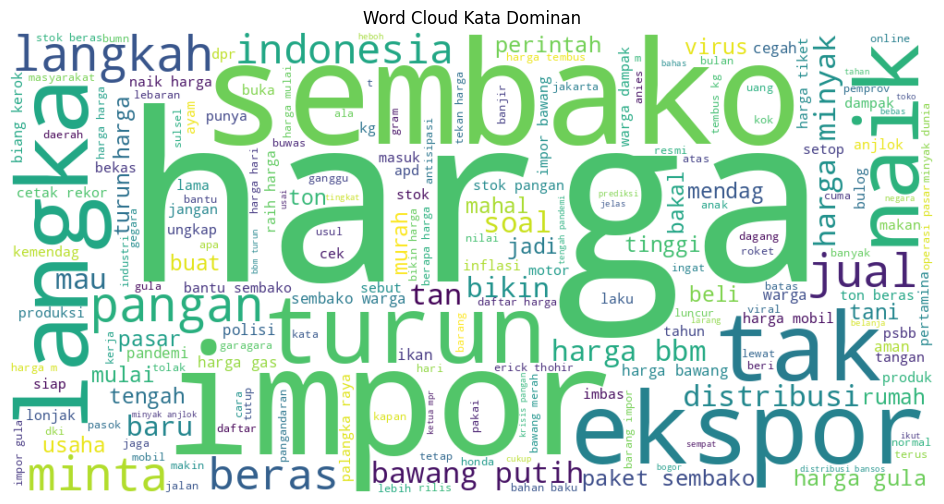

In [ ]:
# =========================================================
# WORD CLOUD KATA DOMINAN
# =========================================================
from wordcloud import WordCloud
all_text = " ".join(df_filtered['clean_text'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.title('Word Cloud Kata Dominan')

plt.show()

In [ ]:
# 1. SETUP STOPWORDS
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()

# =========================================================
# TAHAP 1: BEFORE (Data Teks Asli)
# =========================================================
print("="*60)
print("1. BEFORE (Original Data)")
print("="*60)
display(df_filtered[['clean_text', 'label']].head(10))

# =========================================================
# TAHAP 2: AFTER (Feature Extraction Perbandingan)
# =========================================================
print("\n" + "="*60)
print("2. AFTER (Feature Extraction - 4 Perbandingan)")
print("="*60)

# Fungsi untuk bikin tabel bervariasi (ngambil kolom yang paling aktif/sering muQncul)
def get_varied_df(matrix, vectorizer):
    features = vectorizer.get_feature_names_out()
    full_df = pd.DataFrame(matrix.toarray(), columns=features)

    # Ambil 15 kolom teratas berdasarkan jumlah kemunculan
    top_cols = full_df.sum().sort_values(ascending=False).head(15).index
    return full_df[top_cols].head(10)

# --- Metode 1: Bag of Words (BoW / Unigram) ---
vec_bow = CountVectorizer(stop_words=stopwords, ngram_range=(1, 1), max_features=500)
bow_matrix = vec_bow.fit_transform(df_filtered['clean_text'].astype(str))
print("\n[ AFTER: Metode Bag of Words (Unigram - 1 Kata) ]")
display(get_varied_df(bow_matrix, vec_bow))

# --- Metode 2: TF-IDF ---
vec_tfidf = TfidfVectorizer(stop_words=stopwords, max_features=500)
tfidf_matrix = vec_tfidf.fit_transform(df_filtered['clean_text'].astype(str))
print("\n[ AFTER: Metode TF-IDF (Weighting - Angka Desimal) ]")
display(get_varied_df(tfidf_matrix, vec_tfidf))


1. BEFORE (Original Data)


,clean_text,label
0,terbit resi pertama srg konawe bantu tahan pan...,netral
2,banyak slot terbang internasional kosong langk...,negatif
3,atur wajib kapal ganggu ekspor batu bara,negatif
4,izin impor lelet waspada ekspor makin loyo,negatif
5,inflasi rendah daya beli turun kata bi,positif
6,ct bicara inflasi rendah ekonomi baik daya bel...,positif
7,usai cetak rekor harga hari turun ceceng,positif
8,ekspor impor mandek garagara banjir,negatif
9,diskon libur tambah kartu sembako tepis,netral
11,harga ayam potong bandung capai,netral



2. AFTER (Feature Extraction - 4 Perbandingan)

[ AFTER: Metode Bag of Words (Unigram - 1 Kata) ]


,harga,sembako,impor,turun,ekspor,pangan,naik,beras,gula,langka,tak,warga,bawang,langkah,stok
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
6,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
7,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
8,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
9,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0



[ AFTER: Metode TF-IDF (Weighting - Angka Desimal) ]


,harga,sembako,impor,turun,ekspor,naik,langka,beras,pangan,gula,tak,langkah,warga,bawang,mobil
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.336341,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.588818,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.242634,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.000000,0.000000,0.337331,0.000000,0.373764,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.241119,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
5,0.000000,0.000000,0.000000,0.218301,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
6,0.156028,0.000000,0.000000,0.305841,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
7,0.000000,0.000000,0.346317,0.000000,0.383721,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
8,0.000000,0.338826,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
9,0.212605,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0


In [ ]:
# =========================================================
# FUNGSI (PUNYA LO - SUDAH BAGUS)
# =========================================================
def get_nonzero_ngram_df(matrix, vectorizer):
    features = vectorizer.get_feature_names_out()
    full_df = pd.DataFrame(matrix.toarray(), columns=features)

    # ambil 15 fitur paling sering muncul
    top_cols = full_df.sum().sort_values(ascending=False).head(15).index

    # ambil baris yang punya nilai > 0
    df_nonzero = full_df[full_df[top_cols].sum(axis=1) > 0]

    if not df_nonzero.empty:
        return df_nonzero[top_cols].head(10)
    else:
        return full_df[full_df.sum(axis=1) > 0][top_cols].head(10)


# =========================================================
# BIGRAM
# =========================================================
vec_bigram = CountVectorizer(ngram_range=(2,2))
bigram_matrix = vec_bigram.fit_transform(df_filtered['clean_text'].astype(str))

print("\n[ AFTER: Metode N-Gram (Bigram - 2 Kata) ]")
print("Menampilkan baris yang mendeteksi kombinasi 2 kata:")
display(get_nonzero_ngram_df(bigram_matrix, vec_bigram))


# =========================================================
# TRIGRAM
# =========================================================
vec_trigram = CountVectorizer(ngram_range=(3,3))
trigram_matrix = vec_trigram.fit_transform(df_filtered['clean_text'].astype(str))

print("\n[ AFTER: Metode N-Gram (Trigram - 3 Kata) ]")
print("Menampilkan baris yang mendeteksi kombinasi 3 kata:")
display(get_nonzero_ngram_df(trigram_matrix, vec_trigram))


[ AFTER: Metode N-Gram (Bigram - 2 Kata) ]
Menampilkan baris yang mendeteksi kombinasi 2 kata:


,bawang putih,harga minyak,harga bbm,paket sembako,harga gula,sembako warga,harga bawang,harga gas,turun harga,harga turun,harga mobil,harga naik,stok pangan,bantu sembako,raih harga
12,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
22,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
26,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
33,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
35,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
38,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
47,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
50,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
56,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0



[ AFTER: Metode N-Gram (Trigram - 3 Kata) ]
Menampilkan baris yang mendeteksi kombinasi 3 kata:


,impor bawang putih,harga bawang putih,paket sembako warga,sembako warga dampak,harga minyak dunia,harga minyak anjlok,turun harga bbm,harga bbm turun,harga gas industri,impor bahan baku,harga tiket pesawat,cetak rekor harga,harga elpiji kg,harga bawang merah,harga cetak rekor
6,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
26,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
30,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
33,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
38,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
41,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
56,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
60,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
65,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
68,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


Pada tahap ini, kami menggunakan metode Bag of Words (1-gram) untuk mengubah teks menjadi representasi numerik berdasarkan frekuensi kemunculan kata.

Pada tahap ini, kami menggunakan TF-IDF (Term Frequency - Inverse Document Frequency) untuk memberikan bobot pada kata berdasarkan tingkat kepentingannya dalam dokumen.

Data Mining

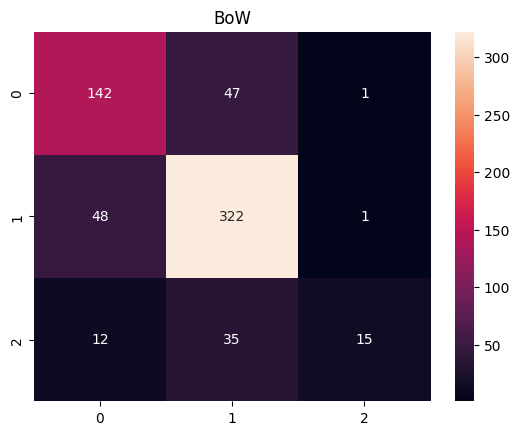

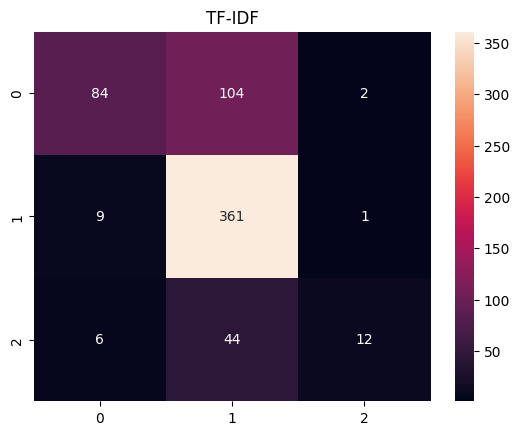

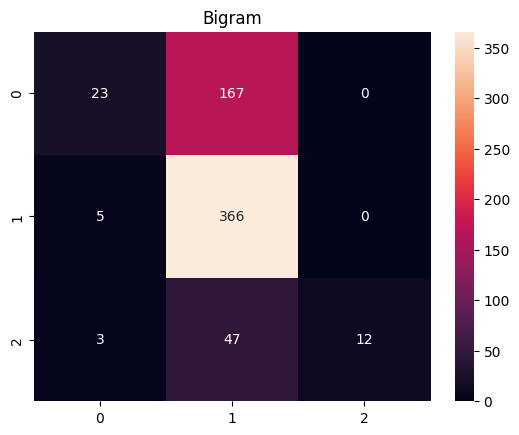

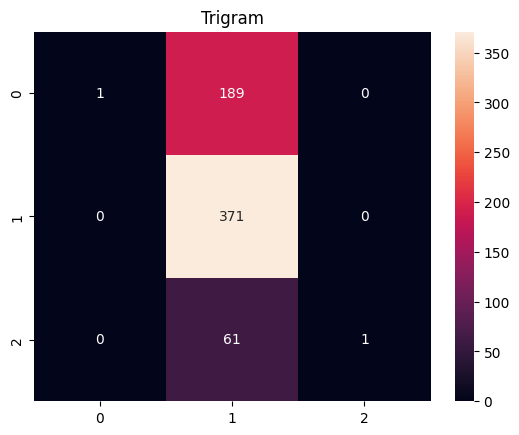

,Metode,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,BoW,76.89,77.68,76.89,75.36
1,TF-IDF,73.35,76.07,73.35,69.69
2,Bigram,64.37,70.16,64.37,55.41
3,Trigram,59.87,76.03,59.87,45.18


In [ ]:
# STOPWORDS MODEL (ANTI LEAKAGE)
label_leak_words = [
    'naik','turun','mahal','murah','impor','ekspor',
    'krisis','lancar','stabil','bantuan','subsidi'
]

stopwords_model = stopwords + label_leak_words

X = df_filtered['clean_text']
y = df_filtered['label']

metode = {
    "BoW": CountVectorizer(stop_words=stopwords_model, max_features=500),
    "TF-IDF": TfidfVectorizer(stop_words=stopwords_model, max_features=500),
    "Bigram": CountVectorizer(ngram_range=(2,2), stop_words=stopwords_model, max_features=500),
    "Trigram": CountVectorizer(ngram_range=(3,3), stop_words=stopwords_model, max_features=500)
}

hasil = []

for nama, vec in metode.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    X_train_vec = vec.fit_transform(X_train)
    X_test_vec = vec.transform(X_test)

    model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=10)
    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)
    report = classification_report(y_test, y_pred, output_dict=True)

    hasil.append({
        "Metode": nama,
        "Accuracy (%)": round(report['accuracy']*100,2),
        "Precision (%)": round(report['weighted avg']['precision']*100,2),
        "Recall (%)": round(report['weighted avg']['recall']*100,2),
        "F1-Score (%)": round(report['weighted avg']['f1-score']*100,2)
    })

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(nama)
    plt.show()

df_hasil = pd.DataFrame(hasil)
display(df_hasil)

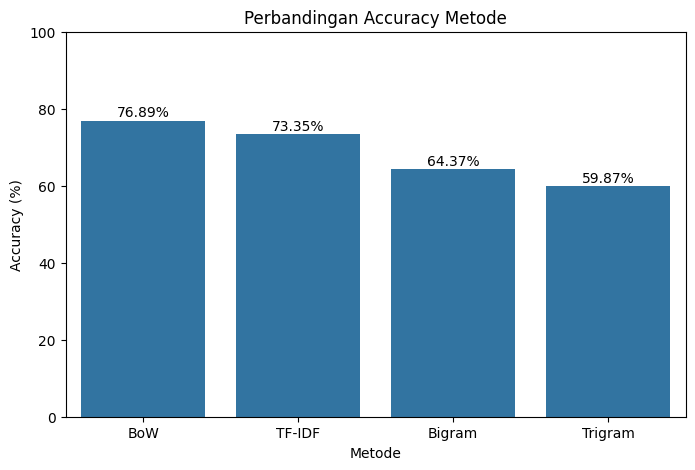

In [ ]:
# =========================================================
# VISUALISASI ACCURACY PER METODE
# =========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=df_hasil['Metode'],
    y=df_hasil['Accuracy (%)']
)

plt.title('Perbandingan Accuracy Metode')
plt.xlabel('Metode')
plt.ylabel('Accuracy (%)')

plt.ylim(0,100)

for i, v in enumerate(df_hasil['Accuracy (%)']):
    plt.text(i, v+1, f'{v}%', ha='center')

plt.show()

In [ ]:
# =========================================================
# ANALISIS KATA DENGAN BOBOT TERTINGGI (TOP FEATURES)
# =========================================================

def get_top_weights(matrix, vectorizer, n=10):
    # Hitung total bobot untuk setiap fitur/kata
    weights = matrix.sum(axis=0).A1
    features = vectorizer.get_feature_names_out()

    # Masukkan ke DataFrame dan urutkan
    df_weights = pd.DataFrame({'keyword': features, 'total_weight': weights})
    return df_weights.sort_values(by='total_weight', ascending=False).head(n)

print("\n" + "="*60)
print("📊 RINGKASAN KATA DENGAN BOBOT TERTINGGI")
print("="*60)

# 1. Top BoW (Frekuensi Kemunculan Terbanyak)
print("\n[ Top 10 - Bag of Words (Paling Sering Muncul) ]")
print(get_top_weights(bow_matrix, vec_bow))

# 2. Top TF-IDF (Paling Penting/Unik dalam Dokumen)
print("\n[ Top 10 - TF-IDF (Bobot Kepentingan Tertinggi) ]")
print(get_top_weights(tfidf_matrix, vec_tfidf))

# 3. Top Bigram (Pasangan 2 Kata Terpopuler)
print("\n[ Top 10 - Bigram (2 Kata) ]")
print(get_top_weights(bigram_matrix, vec_bigram))

# 4. Top Trigram (Rangkaian 3 Kata Terpopuler)
print("\n[ Top 10 - Trigram (3 Kata) ]")
print(get_top_weights(trigram_matrix, vec_trigram))


📊 RINGKASAN KATA DENGAN BOBOT TERTINGGI

[ Top 10 - Bag of Words (Paling Sering Muncul) ]
     keyword  total_weight
165    harga          1384
410  sembako           336
180    impor           331
477    turun           237
133   ekspor           233
330   pangan           208
305     naik           206
64     beras           198
160     gula           162
243   langka           152

[ Top 10 - TF-IDF (Bobot Kepentingan Tertinggi) ]
     keyword  total_weight
165    harga    279.419393
410  sembako    102.198296
180    impor    100.946455
477    turun     87.796299
133   ekspor     79.825133
305     naik     78.601067
243   langka     69.459866
64     beras     65.244545
330   pangan     65.228231
160     gula     57.120847

[ Top 10 - Bigram (2 Kata) ]
             keyword  total_weight
1107    bawang putih            78
3952    harga minyak            75
3792       harga bbm            71
8284   paket sembako            67
3859      harga gula            66
10467  sembako warga    

In [ ]:
from google.colab import files
files.download('model_decision_tree.pkl')
files.download('vectorizer.pkl')

FileNotFoundError: Cannot find file: model_decision_tree.pkl

Pada tahap ini, kami mengidentifikasi kata yang paling sering muncul dalam dataset untuk memahami pola dominan dalam data.

In [ ]:
# =========================
# SAVE DATA
# =========================
df_filtered.to_csv('/content/drive/MyDrive/dataset/dataset_transform_final.csv', index=False)

print("Dataset transformasi berhasil disimpan!")

In [ ]:
# =========================
# SAVE MODEL KE GOOGLE DRIVE
# =========================
import joblib

# save model
joblib.dump(
    model,
    '/content/drive/MyDrive/model_decision_tree.pkl'
)

# save vectorizer
joblib.dump(
    vec_bow,
    '/content/drive/MyDrive/vectorizer.pkl'
)

print("Model & vectorizer berhasil disimpan ke Google Drive!")

Model & vectorizer berhasil disimpan ke Google Drive!
